# 48. Which way a spiral turns: the Dzyaloshinskii-Moriya energy

A spin spiral without spin-orbit coupling does not know which way it turns: the
spiral at `q` and the one at `-q` have the same energy, and so does every
orientation of the plane it turns in, because nothing ties the spins to the
lattice. Spin-orbit coupling does, and in a crystal without an inversion centre
it tells the two senses apart. The energy that does it is the
Dzyaloshinskii-Moriya energy, what selects a cycloid over its mirror image in a
polar magnet and what a spin-polarized STM image of a chiral texture sees.

Here it is computed on the spiral itself, in its one-atom cell, with the coupling
added to first order on top of the spiral computed without it. The crystal is a
nickel chain with an iodine atom beside each Ni-Ni bond, which breaks inversion.
The first-order energy comes out as a vector, `E1 = n . V(q)` with `n` the axis the
spins turn about, and at a quarter turn per cell `V` points along `y`, the normal
to the plane of the atoms, at **-1.21790 meV per cell** in this deliberately small
calculation. A four-cell supercell holding the same spiral explicitly gives
**-1.21790**. Neither Quantum ESPRESSO nor Elk computes this: QE has no spin
spiral, and Elk switches spin-orbit coupling off on one.

The number is the machinery's, not the chain's. At 34 Ry and eight k-points both
the cutoff and the mesh are far from converged for nickel, and the energy is a
remainder of larger k-point contributions of both signs, so it moves a great deal
with either: the same cell gives -2.35 meV at 30 Ry and +0.028 at 40.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
chain = Calculator.from_file(CASES / "nii-chain-spiral.in", PSEUDO, announce=False)
scf = chain.get_scf()
first = chain.get_spiral_spin_orbit_energy()
print("V(q) in meV per cell:", np.round(first.vector_mev, 5))

V(q) in meV per cell: [ 0.     -1.2179  0.    ]


## The spiral, and the coupling on top of it

The spiral is converged without the coupling (`soc_scale = 0` on fully
relativistic datasets), where it is exact in the unit cell: each spin-up
component lives at `k + q/2` and each spin-down one at `k - q/2`. The coupling is
then added as a perturbation. It acts on the orbital motion near each atom and it
is the same in every cell, while the spins turn from one cell to the next, so of
its three spin components only the one along the spiral's axis looks the same in
every cell, and only that one has a first-order energy. That is why the energy is
linear in the axis: one vector gives it for every orientation of the plane.

In [2]:
axes = {"helix, turning about the chain (axis z)": (0, 0, 1),
        "cycloid in the plane of the atoms (axis y)": (0, 1, 0),
        "cycloid across that plane (axis x)": (1, 0, 0)}
for name, axis in axes.items():
    print(f"{name:45s} {first.energy_mev(axis):+.5f} meV per cell")
print("the axis the coupling prefers:", np.round(first.easy_axis, 4) + 0.0)

helix, turning about the chain (axis z)       +0.00000 meV per cell
cycloid in the plane of the atoms (axis y)    -1.21790 meV per cell
cycloid across that plane (axis x)            +0.00000 meV per cell
the axis the coupling prefers: [0. 1. 0.]


Only the cycloid turning in the plane of the atoms feels the coupling at first
order. The mirror in that plane is the reason: it leaves the normal to the plane
as the only direction the vector can point along, so the helix and the other
cycloid get nothing. Reversing the axis is the same texture as reversing `q`,
which is the mirror image of the spiral, and it costs exactly the opposite: the
run at `-q` gives **+1.21791 meV** against **-1.21790**. So the whole
first-order energy is the chirality, and there is no part of it that is even in
`q`.

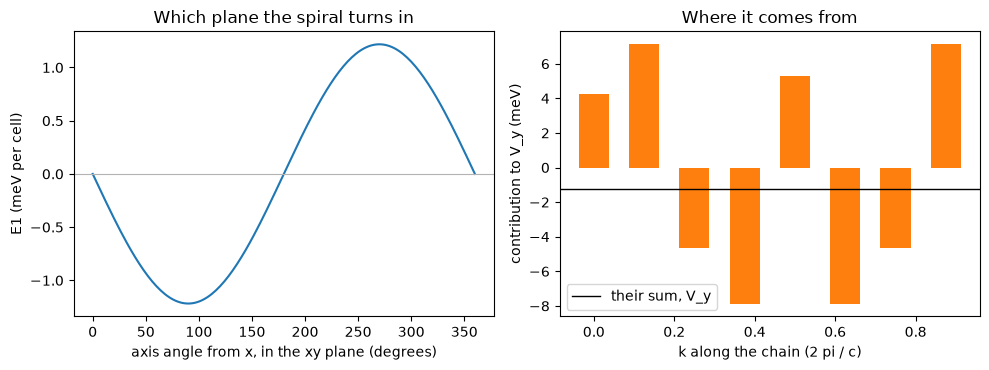

In [3]:
angle = np.linspace(0.0, 2.0 * np.pi, 181)
turned = [first.energy_mev((np.cos(a), np.sin(a), 0.0)) for a in angle]
k = np.arange(len(first.by_k)) / len(first.by_k)

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))
left.plot(np.degrees(angle), turned, color="C0")
left.axhline(0.0, color="0.7", lw=0.8)
left.set(xlabel="axis angle from x, in the xy plane (degrees)",
         ylabel="E1 (meV per cell)", title="Which plane the spiral turns in")
right.bar(k, first.by_k[:, 1] * 13605.693, width=0.6 / len(k), color="C1")
right.axhline(first.vector_mev[1], color="k", lw=1.0, label="their sum, V_y")
right.set(xlabel="k along the chain (2 pi / c)", ylabel="contribution to V_y (meV)",
          title="Where it comes from")
right.legend()
fig.tight_layout()

On the left, the energy as the spiral's axis turns in the plane perpendicular to
the chain: a sinusoid, since the energy is `n . V`, with its minimum at the axis
the coupling prefers and its maximum at the mirror image. On the right, the k-points
of the chain: each contributes several meV, of both signs, and the energy is what
survives their cancellation. That is why eight k-points, as here, are far from a
converged value, and why a converged one needs a dense mesh along the chain.

In [4]:
print(f"{'first order, the spiral in its unit cell':52s}{first.vector_mev[1]:10.5f} meV")
print(f"{'first order, the four-cell supercell':52s}  -1.21790 meV")
print(f"{'the coupling scaled to zero, from 0.05, 0.1, 0.2':52s}  -1.21792 meV")
print(f"{'the second-order odd part, per unit coupling':52s}   0.14801 meV")

first order, the spiral in its unit cell              -1.21790 meV
first order, the four-cell supercell                  -1.21790 meV
the coupling scaled to zero, from 0.05, 0.1, 0.2      -1.21792 meV
the second-order odd part, per unit coupling           0.14801 meV


The second line is the same spiral held explicitly in a cell four times as long,
where nothing is special about the spiral's layout, and it agrees to every digit
printed. The third comes from switching the coupling on in the supercell, at a
tenth and a twentieth of its strength, taking the difference between the two
senses of the spiral, and following it down to zero strength: it lands on the
first-order value. The fourth line is what that same scan says about the full
coupling. The difference between the two senses is not first order alone: there
is a second-order part, here a tenth of the first-order one per unit coupling and
of the opposite sign. How much it matters depends on the crystal: on the same
chain at 40 Ry, where the first-order energy nearly cancels over the k-points,
the second-order part is seventeen times larger than it. The first-order energy
is always the right limit of weak coupling, and it is the whole chirality energy
only where that limit is reached.

## How it works

The coupling is a property of each atom, fixed to the lattice, while the spins
turn from cell to cell. In a frame that turns with the spins, the part of the
coupling along the spiral's axis is the same everywhere, and its average over the
occupied states feels which way the spins wind as seen from the side the iodine
sits on. The parts across the axis see a spin that has turned by a different
angle in every cell, and averaged over the cells they cancel, so they only act
by mixing states a wavevector `q` apart, which is the second order above. The
first-order energy is the derivative of the free energy with respect to the
coupling strength at zero, taken of the energy itself on the spiral in its own
unit cell.

*The checks behind these numbers are in `tests/regression/test_spiral_soc.py`
and `tests/unit/test_spiral_soc.py`.*